# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
# from sklearn...
# import statsmodels.api as sm
# import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [4]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


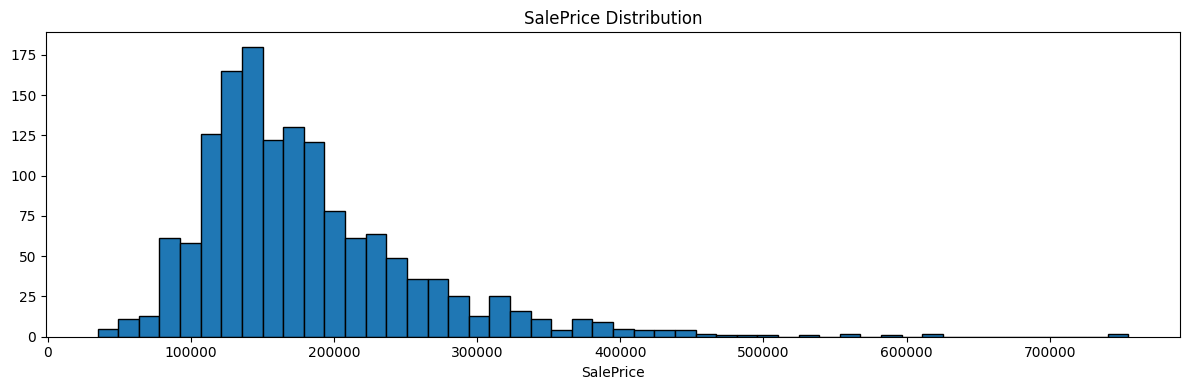

Skewness: 1.883


In [5]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.